## <span style="color: #ffffff;"><b>Projeto Final de Conclusão de Módulo</b></span>

Flávio Garcia Torres

### <span style="color: #05f509;"><b>Cenário</b></span>

Você é um analista de dados contratado por uma loja de varejo com o objetivo de analisar os dados de vendas e fornecer insights que possam ajudar a melhorar as operações e o desempenho da loja.

### <span style="color: #05f509;"><b>Conjunto de Dados</b></span>

Os dados utilizados para a análise incluem informações diárias sobre vendas, categorias de produtos, preços, quantidades vendidas, descontos aplicados e algumas características de clientes (idade e renda) do último ano de operação da empresa. Os dados estão no arquivo vendas_supermercado_com_cliente.csv.

### <span style="color: #05f509;"><b>Objetivo</b></span>

Sua missão é avaliar os dados e responder a 10 perguntas levantadas pela equipe de marketing, que estão listadas abaixo:

Para isso, devemos iniciar importando o pandas:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

O arquivo a ser utilizado será o **vendas_supermercado_com_cliente.csv** que será importado com o seguinte comando e será chamado de df:

In [2]:
df = pd.read_csv('vendas_supermercado_com_cliente.csv')

A seguir teremos o DataFrame a ser trabalhado na análise:

In [3]:
df

,Data,Produto,Categoria,Preço,Quantidade,Desconto,Total_Venda,Idade,Renda
0,2023-01-01,Maçãs,Alimentos Frescos,16.46,10,0.00,164.6000,49,2715.61
1,2023-01-01,Bananas,Alimentos Frescos,2.39,4,0.00,9.5600,29,2280.15
2,2023-01-01,Laranjas,Alimentos Frescos,8.38,5,0.00,41.9000,67,4419.56
3,2023-01-01,Tomates,Alimentos Frescos,2.03,15,0.00,30.4500,29,3809.17
4,2023-01-01,Alface,Alimentos Frescos,37.14,14,0.00,519.9600,24,1013.42
...,...,...,...,...,...,...,...,...,...
20070,2023-12-31,Produtos de higiene para pets,Pet Shop,26.62,15,0.21,315.4470,39,2475.82
20071,2023-12-31,Panelas,Utilidades Domésticas,33.00,19,0.15,532.9500,25,4766.49
20072,2023-12-31,Talheres,Utilidades Domésticas,27.60,12,0.29,235.1520,65,3367.68
20073,2023-12-31,Copos,Utilidades Domésticas,15.35,13,0.25,149.6625,42,3823.50


Ao analisar as informações dos dados com `info()`, verifiquei que o tipo de dados da coluna **Data** estão como string:

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20075 entries, 0 to 20074
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Data         20075 non-null  str    
 1   Produto      20075 non-null  str    
 2   Categoria    20075 non-null  str    
 3   Preço        20075 non-null  float64
 4   Quantidade   20075 non-null  int64  
 5   Desconto     20075 non-null  float64
 6   Total_Venda  20075 non-null  float64
 7   Idade        20075 non-null  int64  
 8   Renda        20075 non-null  float64
dtypes: float64(4), int64(2), str(3)
memory usage: 1.4 MB


Como utilizarei a data para realizar a análise foi necessário a conversão desse tipo de dado para `datetime`

In [5]:
df['Data'] = pd.to_datetime(df['Data'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20075 entries, 0 to 20074
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Data         20075 non-null  datetime64[us]
 1   Produto      20075 non-null  str           
 2   Categoria    20075 non-null  str           
 3   Preço        20075 non-null  float64       
 4   Quantidade   20075 non-null  int64         
 5   Desconto     20075 non-null  float64       
 6   Total_Venda  20075 non-null  float64       
 7   Idade        20075 non-null  int64         
 8   Renda        20075 non-null  float64       
dtypes: datetime64[us](1), float64(4), int64(2), str(2)
memory usage: 1.4 MB


Agora com os dados tratados e a identificação que não há valores nulos, começarei a análise de dados.

#### <span style="color: #acffa6;"><b>1 - Quais foram as categorias de produtos mais vendidos e em quais meses eles tiveram o maior pico de vendas?</b></span>

Verificando as categorias mais vendidas:

In [6]:
df.groupby('Categoria', as_index=False)['Quantidade'].sum().sort_values(ascending=False, by='Quantidade')

,Categoria,Quantidade
0,Alimentos Frescos,54755
7,Produtos de Mercearia,21857
3,Laticínios e Ovos,18602
6,Produtos de Limpeza,18448
5,Produtos de Higiene Pessoal,18374
1,Bebidas,18206
4,Pet Shop,18081
2,Congelados,18051
8,Utilidades Domésticas,14530


A cetegoria mais vendida foi Alimentos Frescos. A seguir a representação gráfica da análise:

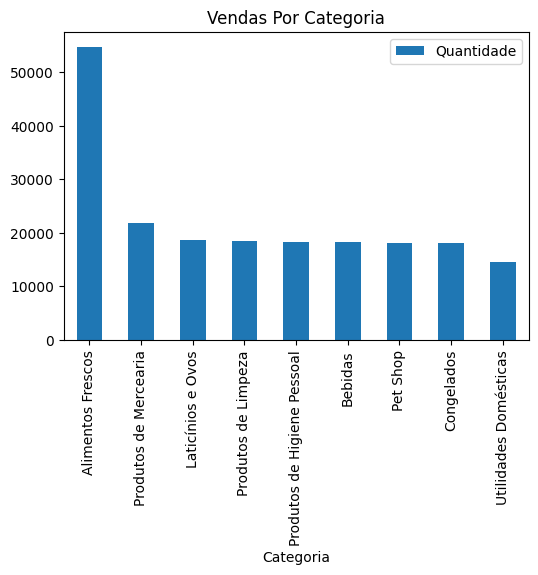

In [7]:
df.groupby('Categoria', as_index=False)['Quantidade'].sum().sort_values(ascending=False, by='Quantidade').plot(
    figsize=(6,4),
    kind = 'bar',
    x = 'Categoria',
    y = 'Quantidade',
    title="Vendas Por Categoria"
)
plt.show()

Abaixo agrupei para saber por mês e por categoria o total vendido e já deixei decrescente. Além disso mudei nome da coluna para mes-ano.

In [8]:
df['mes_ano'] = df['Data'].dt.to_period('M')
categ_mes = df.groupby([df['mes_ano'], 'Categoria'],as_index=False)['Quantidade'].sum().sort_values(ascending=False, by='Quantidade')
categ_mes


,mes_ano,Categoria,Quantidade
18,2023-03,Alimentos Frescos,4832
54,2023-07,Alimentos Frescos,4739
81,2023-10,Alimentos Frescos,4700
45,2023-06,Alimentos Frescos,4663
99,2023-12,Alimentos Frescos,4595
...,...,...,...
53,2023-06,Utilidades Domésticas,1222
80,2023-09,Utilidades Domésticas,1182
26,2023-03,Utilidades Domésticas,1160
17,2023-02,Utilidades Domésticas,1110


Com todas as categorias somadas mês a mês e ordenadas em ordem decrescente, agrupei novamente por categoria e usei o `head(1)` para trazer apenas a primeira linha (maior valor) de cada categoria, trazendo também a informação do mês que foi mais vendido:

In [9]:
resultado = categ_mes.groupby('Categoria').head(1)
resultado.sort_values(by='Categoria')

,mes_ano,Categoria,Quantidade
18,2023-03,Alimentos Frescos,4832
1,2023-01,Bebidas,1651
83,2023-10,Congelados,1649
21,2023-03,Laticínios e Ovos,1681
49,2023-06,Pet Shop,1586
41,2023-05,Produtos de Higiene Pessoal,1641
87,2023-10,Produtos de Limpeza,1650
106,2023-12,Produtos de Mercearia,1950
107,2023-12,Utilidades Domésticas,1308


#### <span style="color: #acffa6;"><b>2 - Qual a média de vendas diárias por categoria de produto?</b></span>

In [10]:
media_dia_categoria = df.groupby(['Data', 'Categoria'])['Quantidade'].sum().groupby('Categoria').mean().reset_index()
media_dia_categoria = media_dia_categoria.rename(columns={'Quantidade': 'Média de Vendas Dia'})
media_dia_categoria

,Categoria,Média de Vendas Dia
0,Alimentos Frescos,150.013699
1,Bebidas,49.879452
2,Congelados,49.454795
3,Laticínios e Ovos,50.964384
4,Pet Shop,49.536986
5,Produtos de Higiene Pessoal,50.339726
6,Produtos de Limpeza,50.542466
7,Produtos de Mercearia,59.882192
8,Utilidades Domésticas,39.808219


Abaixo a representação gráfica:

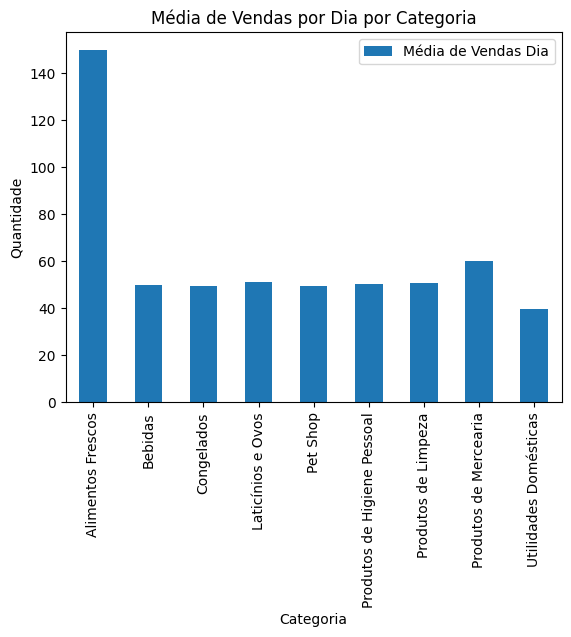

In [11]:
media_dia_categoria = df.groupby(['Data', 'Categoria'])['Quantidade'].sum().groupby('Categoria').mean().reset_index()
media_dia_categoria = media_dia_categoria.rename(columns={'Quantidade': 'Média de Vendas Dia'})
media_dia_categoria.plot(
    kind = 'bar',
    x = 'Categoria',
    title='Média de Vendas por Dia por Categoria'
)
plt.xlabel('Categoria')
plt.ylabel('Quantidade')
plt.show()

#### <span style="color: #acffa6;"><b>3 - Quais produtos apresentam a maior sazonalidade nas vendas (ex.: frutas e vegetais, sorvetes)?</b></span>

O produto com maior indíce de variação foi o Croissant.

In [41]:
agrupado_mes = df.groupby(['Produto', df['Data'].dt.month])['Quantidade'].sum().reset_index()

sazonalidade = (agrupado_mes.groupby(['Produto'])['Quantidade'].agg(['mean', 'std'])
    .reset_index()
)

sazonalidade['variacao'] = sazonalidade['std'] / sazonalidade['mean']

sazonalidade = sazonalidade.sort_values('variacao', ascending=False)
sazonalidade

,Produto,mean,std,variacao
13,Croissants,305.166667,47.615569,0.156031
43,Sabão em pó,309.500000,45.707568,0.147682
28,Ovos,313.166667,43.228428,0.138036
37,Pão integral,305.000000,41.880783,0.137314
33,Pratos prontos congelados,303.000000,41.314756,0.136352
35,"Produtos descartáveis (pratos, copos, talheres)",290.166667,37.030291,0.127617
45,Shampoos,306.500000,39.006992,0.127266
42,Sabonetes,308.500000,38.979015,0.126350
16,Esponjas,302.000000,37.670823,0.124738
52,Vinhos,292.166667,35.588132,0.121808


#### <span style="color: #acffa6;"><b>4 - Quais as faixas etárias contribuíram mais para as vendas totais? Para responder essa pergunta, crie uma coluna com a faixa etária, considerando: entre 18 e 35 (jovem), entre 36 e 59 (adulto) e acima de 60 anos (idoso).</b></span>

Criei a coluna nova de acordo com os parâmetros:

In [17]:
df.loc[(df['Idade'] >= 18) & (df['Idade'] <= 35), 'Faixa_Etaria'] = 'Jovem'
df.loc[(df['Idade'] >= 36) & (df['Idade'] <= 59), 'Faixa_Etaria'] = 'Adulto'
df.loc[df['Idade'] >= 60, 'Faixa_Etaria'] = 'Idoso'
df

,Data,Produto,Categoria,Preço,Quantidade,Desconto,Total_Venda,Idade,Renda,mes_ano,Faixa_Etaria
0,2023-01-01,Maçãs,Alimentos Frescos,16.46,10,0.00,164.6000,49,2715.61,2023-01,Adulto
1,2023-01-01,Bananas,Alimentos Frescos,2.39,4,0.00,9.5600,29,2280.15,2023-01,Jovem
2,2023-01-01,Laranjas,Alimentos Frescos,8.38,5,0.00,41.9000,67,4419.56,2023-01,Idoso
3,2023-01-01,Tomates,Alimentos Frescos,2.03,15,0.00,30.4500,29,3809.17,2023-01,Jovem
4,2023-01-01,Alface,Alimentos Frescos,37.14,14,0.00,519.9600,24,1013.42,2023-01,Jovem
...,...,...,...,...,...,...,...,...,...,...,...
20070,2023-12-31,Produtos de higiene para pets,Pet Shop,26.62,15,0.21,315.4470,39,2475.82,2023-12,Adulto
20071,2023-12-31,Panelas,Utilidades Domésticas,33.00,19,0.15,532.9500,25,4766.49,2023-12,Jovem
20072,2023-12-31,Talheres,Utilidades Domésticas,27.60,12,0.29,235.1520,65,3367.68,2023-12,Idoso
20073,2023-12-31,Copos,Utilidades Domésticas,15.35,13,0.25,149.6625,42,3823.50,2023-12,Adulto


Agrupando por faixa etária para saber o total em vendas (R$)

In [18]:
por_idade = df.groupby('Faixa_Etaria', as_index=False)['Total_Venda'].sum().sort_values(ascending=False, by='Total_Venda').round(2)
por_idade

,Faixa_Etaria,Total_Venda
0,Adulto,2102041.77
2,Jovem,1537183.38
1,Idoso,1297252.20


Abaixo a representação gráfica:

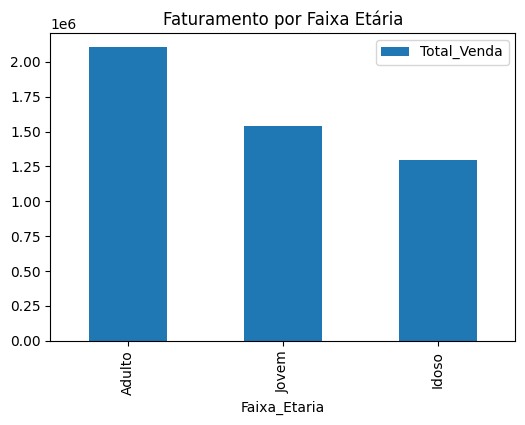

In [19]:
por_idade.plot(
    kind = 'bar',
    figsize=(6,4),
    x = 'Faixa_Etaria',
    title='Faturamento por Faixa Etária'
)
plt.show()

#### <span style="color: #acffa6;"><b>5 - Qual é a relação entre a idade dos clientes e a categoria de produto mais vendida para cada?</b></span>

Em todas as faixas etárias a categoria mais vendida foi a de Alimentos Frescos sendo o grupo de Adultos a que mais consumiu.

In [20]:
categ_faixa_etaria = df.groupby(['Faixa_Etaria','Categoria'], as_index=False)['Quantidade'].sum().sort_values(ascending=False, by=['Faixa_Etaria', 'Quantidade'])

faixa_jovem = categ_faixa_etaria[categ_faixa_etaria['Faixa_Etaria'] == 'Jovem']
faixa_adulto = categ_faixa_etaria[categ_faixa_etaria['Faixa_Etaria'] == 'Adulto']
faixa_idoso = categ_faixa_etaria[categ_faixa_etaria['Faixa_Etaria'] == 'Idoso']

In [21]:
faixa_jovem

,Faixa_Etaria,Categoria,Quantidade
18,Jovem,Alimentos Frescos,17178
25,Jovem,Produtos de Mercearia,6870
24,Jovem,Produtos de Limpeza,6151
23,Jovem,Produtos de Higiene Pessoal,6005
21,Jovem,Laticínios e Ovos,5856
20,Jovem,Congelados,5745
19,Jovem,Bebidas,5681
22,Jovem,Pet Shop,5604
26,Jovem,Utilidades Domésticas,4465


In [22]:
faixa_adulto

,Faixa_Etaria,Categoria,Quantidade
0,Adulto,Alimentos Frescos,23212
7,Adulto,Produtos de Mercearia,9622
4,Adulto,Pet Shop,7989
3,Adulto,Laticínios e Ovos,7875
5,Adulto,Produtos de Higiene Pessoal,7812
2,Adulto,Congelados,7499
6,Adulto,Produtos de Limpeza,7497
1,Adulto,Bebidas,7491
8,Adulto,Utilidades Domésticas,6012


In [23]:
faixa_idoso

,Faixa_Etaria,Categoria,Quantidade
9,Idoso,Alimentos Frescos,14365
16,Idoso,Produtos de Mercearia,5365
10,Idoso,Bebidas,5034
12,Idoso,Laticínios e Ovos,4871
11,Idoso,Congelados,4807
15,Idoso,Produtos de Limpeza,4800
14,Idoso,Produtos de Higiene Pessoal,4557
13,Idoso,Pet Shop,4488
17,Idoso,Utilidades Domésticas,4053


#### <span style="color: #acffa6;"><b>6 - Qual a distribuição das vendas ao longo dos dias da semana?</b></span>

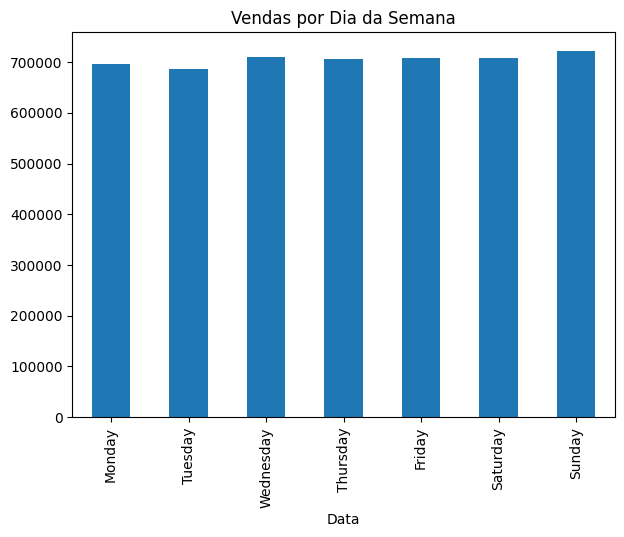

In [24]:
ordem = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

df.groupby(df['Data'].dt.day_name())['Total_Venda'].sum().reindex(ordem).plot(
    kind='bar',
    figsize=(7,5),
    title="Vendas por Dia da Semana"
)
plt.show()

#### <span style="color: #acffa6;"><b>7 - Como as vendas mensais se comparam antes e durante a Black Friday?</b></span>

In [25]:
# df.groupby('mes_ano')['Total_Venda'].sum().plot(
#     kind='bar',
#     title="Vendas Mensais"
# )

media_nov = df.loc[df['mes_ano'] == '2023-11', 'Total_Venda'].mean()
media_outros = df.loc[df['mes_ano'] != '2023-11', 'Total_Venda'].mean()

print(f'A média de vendas em Novembro foi de {media_nov:.2f} enquanto a dos outros meses foi de {media_outros:.2f}')

A média de vendas em Novembro foi de 233.78 enquanto a dos outros meses foi de 246.99


#### <span style="color: #acffa6;"><b>8 - Qual é o ticket médio (valor médio das vendas) por faixa etária e como ele varia entre diferentes categorias de produto?</b></span>

In [26]:
# Valor médio por faixa etária
df.groupby('Faixa_Etaria')['Total_Venda'].mean()

Faixa_Etaria
Adulto    247.794621
Idoso     247.331211
Jovem     242.190543
Name: Total_Venda, dtype: float64

<Axes: title={'center': 'Ticket Médio por Faixa Etária'}, xlabel='Faixa_Etaria'>

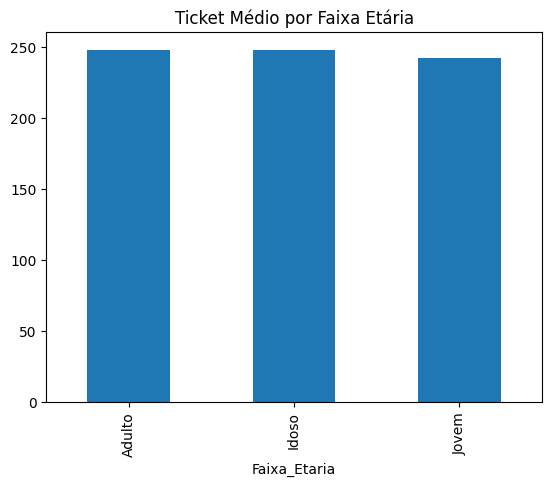

In [27]:
df.groupby('Faixa_Etaria')['Total_Venda'].mean().plot(
    kind='bar',
    title='Ticket Médio por Faixa Etária'
)

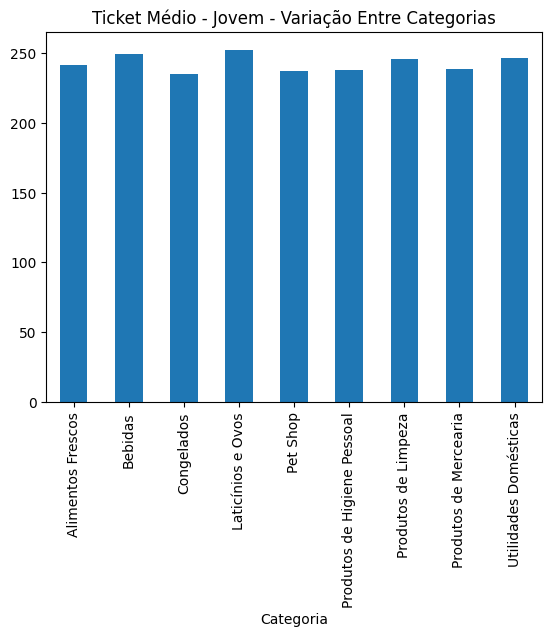

In [28]:
# Variação entre categorias de produtos
df[df['Faixa_Etaria'] == 'Jovem'].groupby('Categoria')['Total_Venda'].mean().plot(
    kind='bar',
    title='Ticket Médio - Jovem - Variação Entre Categorias'
)
plt.show()

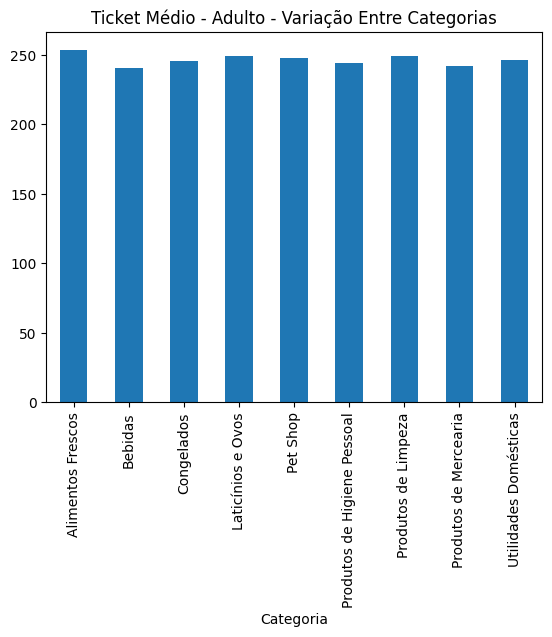

In [29]:
df[df['Faixa_Etaria'] == 'Adulto'].groupby('Categoria')['Total_Venda'].mean().plot(
    kind='bar',
    title='Ticket Médio - Adulto - Variação Entre Categorias'
)
plt.show()

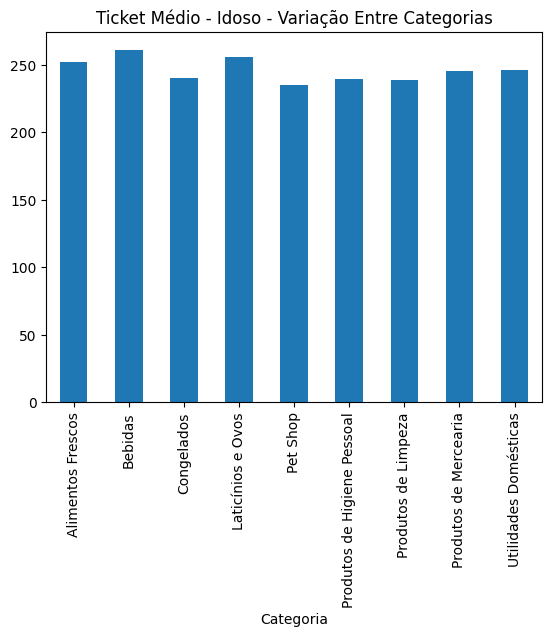

In [30]:
df[df['Faixa_Etaria'] == 'Idoso'].groupby('Categoria')['Total_Venda'].mean().plot(
    kind='bar',
    title='Ticket Médio - Idoso - Variação Entre Categorias'
)
plt.show()

#### <span style="color: #acffa6;"><b>9 - Comparando a semana da “Black Friday” com a do Natal, qual semana a empresa teve melhores desempenhos em relação à média de vendas?</b></span>

In [31]:
# comparar mês de NOV e DEZ, criando uma coluna de Data Especial

df.loc[(df['Data'] >= '2023-11-17') & (df['Data'] <= '2023-11-24'), 'data_especial'] = 'Black Friday'
df.loc[(df['Data'] >= '2023-12-18') & (df['Data'] <= '2023-12-25'), 'data_especial'] = 'Natal'

semana_especial = df.groupby('data_especial')['Total_Venda'].mean().round(2).reset_index().rename(columns={'data_especial' : 'Semana Especial','Total_Venda' : 'Valor Médio de Vendas'})
semana_especial

,Semana Especial,Valor Médio de Vendas
0,Black Friday,217.44
1,Natal,224.01


#### <span style="color: #acffa6;"><b>10 - Qual foi o impacto das promoções (descontos aplicados) nas vendas? Quais produtos tiveram o maior aumento nas vendas durante as promoções?</b></span>

Analisando produto a produto não houve melhora significativa nas vendas com promoções, em alguns casos vendeu até menos.

In [75]:
df['Promocao'] = df['Desconto'] > 0
comparacao = df.groupby(['Produto', 'Promocao'])['Quantidade'].mean().unstack()
comparacao = comparacao.rename(columns={False: 'media_sem_promocao', True: 'media_com_promocao'}).reset_index()
comparacao


Promocao,Produto,media_sem_promocao,media_com_promocao
0,Alface,10.564014,9.723684
1,Amaciantes,10.006920,9.697368
2,Arroz,9.816609,9.355263
3,Atum,10.408304,10.421053
4,Azeite,9.813149,10.802632
5,Bananas,9.328720,10.328947
6,Brinquedos para pets,9.553633,9.013158
7,Carne bovina,10.207612,9.526316
8,Carne suína,9.785467,10.236842
9,Cenouras,9.730104,10.013158


O produto com maior variação positiva na média de vendas foi o Frango:

In [79]:
comparacao['variacao'] = comparacao['media_com_promocao'] - comparacao['media_sem_promocao']
comparacao.sort_values(ascending=False, by='variacao').head(5)

Promocao,Produto,media_sem_promocao,media_com_promocao,variacao
19,Frango,9.989619,11.381579,1.391960
17,Farinha,9.813149,11.052632,1.239483
5,Bananas,9.328720,10.328947,1.000228
4,Azeite,9.813149,10.802632,0.989483
48,Talheres,10.176471,11.131579,0.955108
